In [11]:
import pandas as pd
import numpy as np
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

os.makedirs("data/models", exist_ok=True)
os.makedirs("data/models/shap", exist_ok=True)

X_train = pd.read_csv("data/ml/X_train.csv", index_col=0, parse_dates=True)
X_test  = pd.read_csv("data/ml/X_test.csv",  index_col=0, parse_dates=True)
y_train = pd.read_csv("data/ml/y_train.csv", index_col=0, parse_dates=True).squeeze()
y_test  = pd.read_csv("data/ml/y_test.csv",  index_col=0, parse_dates=True).squeeze()
feature_cols = joblib.load("data/ml/feature_cols.pkl")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Train Target 分布: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Test  Target 分布: {y_test.value_counts(normalize=True).round(3).to_dict()}")

X_train: (47557, 23)
X_test:  (13121, 23)
Train Target 分布: {1: 0.518, 0: 0.482}
Test  Target 分布: {1: 0.538, 0: 0.462}


In [12]:
def walk_forward_evaluate(model_class, params, X, y, n_splits=5):
    """
    Walk-forward cross validation
    严格按时序分割，绝不让未来数据进入训练集
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_tr = X.iloc[train_idx]
        y_tr = y.iloc[train_idx]
        X_val = X.iloc[val_idx]
        y_val = y.iloc[val_idx]

        print("=" * 60)
        print(f"Fold {fold+1}")
        print(f"Train: {X_tr.index.min().date()} ~ {X_tr.index.max().date()}")
        print(f"Valid: {X_val.index.min().date()} ~ {X_val.index.max().date()}")

        model = model_class(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        y_prob = model.predict_proba(X_val)[:, 1]

        acc = accuracy_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        fold_results.append({"fold": fold + 1, "accuracy": acc, "auc": auc})
        print(f"Accuracy={acc:.4f} | AUC={auc:.4f}")

    df_results = pd.DataFrame(fold_results)
    print("\n=== CV Summary ===")
    print(f"Mean Accuracy: {df_results['accuracy'].mean():.4f} ± {df_results['accuracy'].std():.4f}")
    print(f"Mean AUC:      {df_results['auc'].mean():.4f} ± {df_results['auc'].std():.4f}")
    return df_results

=== LightGBM Walk-forward CV ===
Fold 1
Train: 2019-03-20 ~ 2020-01-29
Valid: 2020-01-29 ~ 2020-11-24
[LightGBM] [Info] Number of positive: 4327, number of negative: 3600
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4080
[LightGBM] [Info] Number of data points in the train set: 7927, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.545856 -> initscore=0.183941
[LightGBM] [Info] Start training from score 0.183941
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further sp

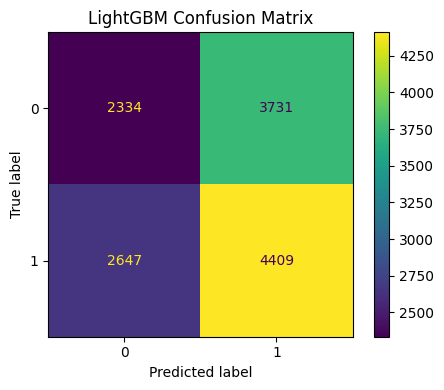

In [13]:
print("=== LightGBM Walk-forward CV ===")
lgb_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "num_leaves": 31,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1
}

from lightgbm import LGBMClassifier
lgb_cv_results = walk_forward_evaluate(LGBMClassifier, lgb_params, X_train, y_train)

lgb_model = LGBMClassifier(**lgb_params)
lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
lgb_acc  = accuracy_score(y_test, lgb_pred)
lgb_auc  = roc_auc_score(y_test, lgb_prob)

print(f"\nLightGBM Test Set:")
print(f"  Accuracy: {lgb_acc:.4f}")
print(f"  AUC:      {lgb_auc:.4f}")
print(classification_report(y_test, lgb_pred, target_names=["Down", "Up"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, lgb_pred, ax=ax)
plt.title("LightGBM Confusion Matrix")
plt.tight_layout()
plt.savefig("data/models/lgb_confusion_matrix.png", dpi=150)
plt.show()

=== XGBoost Walk-forward CV ===
Fold 1
Train: 2019-03-20 ~ 2020-01-29
Valid: 2020-01-29 ~ 2020-11-24
Accuracy=0.5105 | AUC=0.5103
Fold 2
Train: 2019-03-20 ~ 2020-11-24
Valid: 2020-11-24 ~ 2021-09-02
Accuracy=0.5196 | AUC=0.5149
Fold 3
Train: 2019-03-20 ~ 2021-09-02
Valid: 2021-09-02 ~ 2022-05-25
Accuracy=0.4990 | AUC=0.4979
Fold 4
Train: 2019-03-20 ~ 2022-05-25
Valid: 2022-05-25 ~ 2023-02-13
Accuracy=0.4947 | AUC=0.4849
Fold 5
Train: 2019-03-20 ~ 2023-02-13
Valid: 2023-02-13 ~ 2023-10-31
Accuracy=0.5064 | AUC=0.5051

=== CV Summary ===
Mean Accuracy: 0.5060 ± 0.0098
Mean AUC:      0.5026 ± 0.0117

XGBoost Test Set:
  Accuracy: 0.5233
  AUC:      0.5185
              precision    recall  f1-score   support

        Down       0.48      0.43      0.45      6065
          Up       0.55      0.61      0.58      7056

    accuracy                           0.52     13121
   macro avg       0.52      0.52      0.52     13121
weighted avg       0.52      0.52      0.52     13121



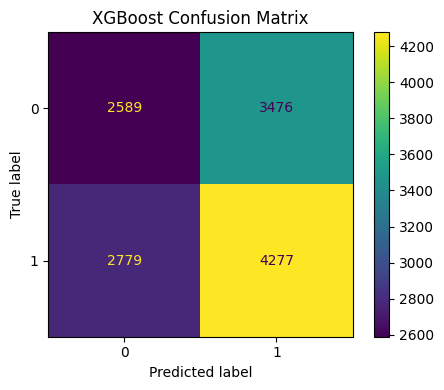

In [14]:
print("=== XGBoost Walk-forward CV ===")
xgb_params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "random_state": 42,
    "n_jobs": -1,
    "eval_metric": "logloss",
    "verbosity": 0
}

from xgboost import XGBClassifier
xgb_cv_results = walk_forward_evaluate(XGBClassifier, xgb_params, X_train, y_train)

xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_auc  = roc_auc_score(y_test, xgb_prob)

print(f"\nXGBoost Test Set:")
print(f"  Accuracy: {xgb_acc:.4f}")
print(f"  AUC:      {xgb_auc:.4f}")
print(classification_report(y_test, xgb_pred, target_names=["Down", "Up"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred, ax=ax)
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.savefig("data/models/xgb_confusion_matrix.png", dpi=150)
plt.show()

=== Model Comparison ===
   model  test_accuracy  test_auc  cv_accuracy_mean  cv_auc_mean
LightGBM       0.513909  0.511015          0.505223     0.503472
 XGBoost       0.523283  0.518512          0.506031     0.502618

最优模型: XGBoost
  Test Accuracy: 0.5233
  Test AUC:      0.5185

模型已保存: data/models/best_model.pkl


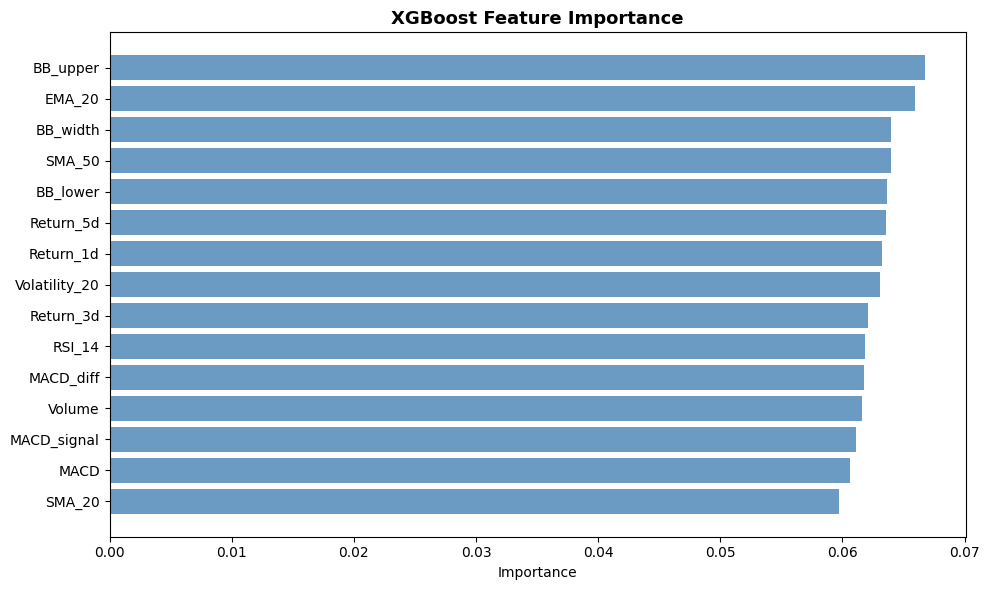

      feature  importance
     BB_upper    0.066758
       EMA_20    0.065973
     BB_width    0.063990
       SMA_50    0.063989
     BB_lower    0.063657
    Return_5d    0.063538
    Return_1d    0.063261
Volatility_20    0.063112
    Return_3d    0.062066
       RSI_14    0.061867
    MACD_diff    0.061726
       Volume    0.061583
  MACD_signal    0.061071
         MACD    0.060611
       SMA_20    0.059750


In [15]:
results_summary = pd.DataFrame([
    {"model": "LightGBM", "test_accuracy": lgb_acc, "test_auc": lgb_auc,
     "cv_accuracy_mean": lgb_cv_results["accuracy"].mean(),
     "cv_auc_mean": lgb_cv_results["auc"].mean()},
    {"model": "XGBoost",  "test_accuracy": xgb_acc, "test_auc": xgb_auc,
     "cv_accuracy_mean": xgb_cv_results["accuracy"].mean(),
     "cv_auc_mean": xgb_cv_results["auc"].mean()},
])

print("=== Model Comparison ===")
print(results_summary.to_string(index=False))

best_row = results_summary.loc[results_summary["test_auc"].idxmax()]
best_name = best_row["model"]
best_model = lgb_model if best_name == "LightGBM" else xgb_model
best_prob  = lgb_prob  if best_name == "LightGBM" else xgb_prob
best_pred  = lgb_pred  if best_name == "LightGBM" else xgb_pred

print(f"\n最优模型: {best_name}")
print(f"  Test Accuracy: {best_row['test_accuracy']:.4f}")
print(f"  Test AUC:      {best_row['test_auc']:.4f}")

joblib.dump(best_model, "data/models/best_model.pkl")
joblib.dump(best_name,  "data/models/best_model_name.pkl")
results_summary.to_csv("data/models/model_comparison.csv", index=False)
print(f"\n模型已保存: data/models/best_model.pkl")

# Feature Importance（带兼容性判断，避免未来换模型类型报错）
if hasattr(best_model, "feature_importances_"):
    imp_values = best_model.feature_importances_
else:
    imp_values = np.abs(best_model.coef_[0])

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": imp_values
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance["feature"][:15][::-1], importance["importance"][:15][::-1],
         color="steelblue", alpha=0.8)
plt.title(f"{best_name} Feature Importance", fontsize=13, fontweight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("data/models/feature_importance.png", dpi=150)
plt.show()

print(importance.head(15).to_string(index=False))

计算 SHAP values（可能需要 1-2 分钟）...


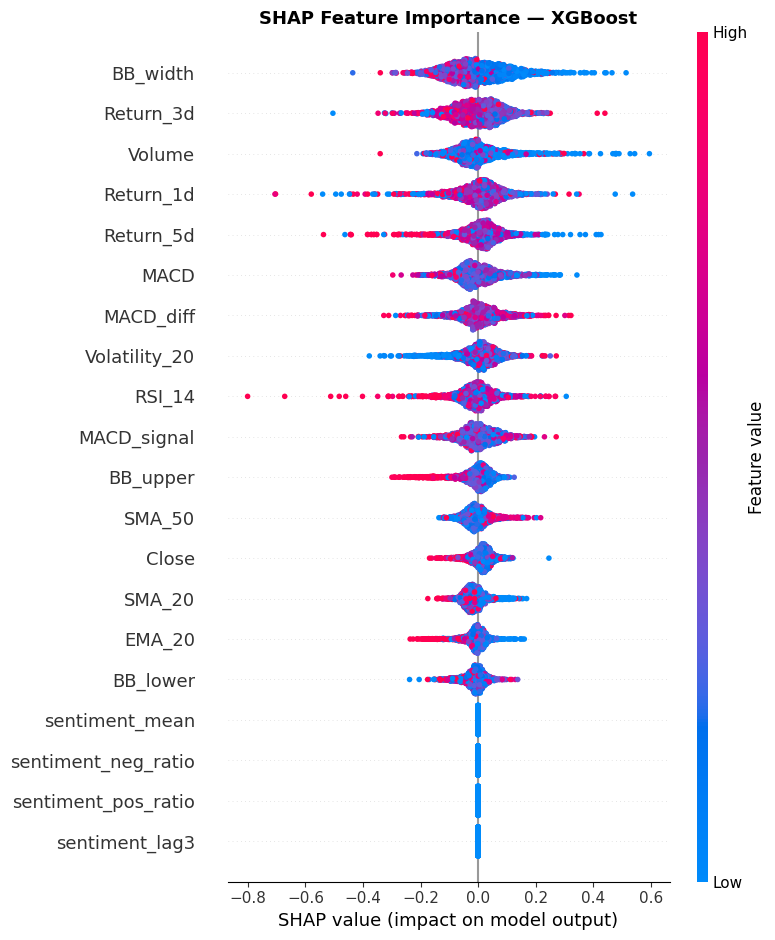

SHAP summary plot 已保存


In [16]:
print("计算 SHAP values（可能需要 1-2 分钟）...")

X_shap = X_test.sample(min(2000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_shap)
shap_vals = shap_values.values

if shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_cols,
                  max_display=20, show=False)
plt.title(f"SHAP Feature Importance — {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/models/shap/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("SHAP summary plot 已保存")

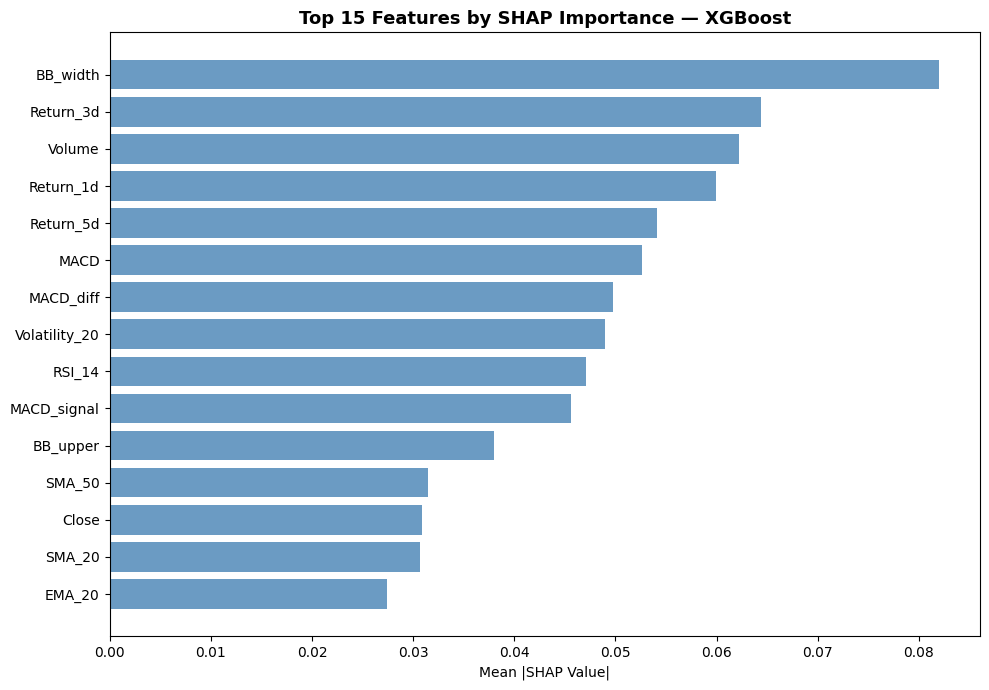

      feature  mean_abs_shap
     BB_width       0.081934
    Return_3d       0.064402
       Volume       0.062256
    Return_1d       0.059976
    Return_5d       0.054102
         MACD       0.052659
    MACD_diff       0.049779
Volatility_20       0.049000
       RSI_14       0.047087
  MACD_signal       0.045611
     BB_upper       0.037986
       SMA_50       0.031460
        Close       0.030899
       SMA_20       0.030643
       EMA_20       0.027442

SHAP explainer 已保存


In [17]:
shap_mean = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_vals).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(shap_mean["feature"][:15][::-1], shap_mean["mean_abs_shap"][:15][::-1],
         color="steelblue", alpha=0.8)
plt.xlabel("Mean |SHAP Value|")
plt.title(f"Top 15 Features by SHAP Importance — {best_name}", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/models/shap/shap_bar.png", dpi=150)
plt.show()

shap_mean.to_csv("data/models/shap/shap_importance.csv", index=False)
print(shap_mean.head(15).to_string(index=False))

joblib.dump(explainer, "data/models/shap/shap_explainer.pkl")
print("\nSHAP explainer 已保存")

In [18]:
schema = joblib.load("data/ml/schema.pkl")
scaler = joblib.load("data/ml/scaler.pkl")

BEST_MODEL = joblib.load("data/models/best_model.pkl")
BEST_NAME  = joblib.load("data/models/best_model_name.pkl")
EXPLAINER  = joblib.load("data/models/shap/shap_explainer.pkl")
SHAP_IMP   = pd.read_csv("data/models/shap/shap_importance.csv")

X_TEST_CACHE = pd.read_csv("data/ml/X_test.csv", index_col=0, parse_dates=True)
META_CACHE   = pd.read_csv("data/ml/test_meta.csv", index_col=0, parse_dates=True)

print(f"缓存加载完成，模型: {BEST_NAME}")
print(f"Schema 字段数: {len(schema)}")

缓存加载完成，模型: XGBoost
Schema 字段数: 23


In [19]:
def QuantTool(ticker: str, input_features: dict = None) -> dict:
    """
    Agent Tool: 返回指定股票的 ML 预测结果 + SHAP 解释
    """
    if input_features is not None:
        X_input = pd.DataFrame([input_features])[schema]
    else:
        # 用位置筛选，而不是日期index筛选，避免同日期多股票冲突
        mask = META_CACHE["ticker"].values == ticker
        if mask.sum() == 0:
            return {"error": f"No test data for {ticker}"}
        
        # 用布尔mask直接对齐 X_TEST_CACHE 的行（两者行顺序一致）
        X_ticker = X_TEST_CACHE.iloc[mask.nonzero()[0]] if hasattr(mask, 'nonzero') else X_TEST_CACHE[mask]
        X_input = X_ticker.tail(1)

    pred = int(BEST_MODEL.predict(X_input)[0])
    prob = float(BEST_MODEL.predict_proba(X_input)[0][1])

    top_features = SHAP_IMP.head(5)[["feature", "mean_abs_shap"]].to_dict("records")

    return {
        "ticker": ticker,
        "model": BEST_NAME,
        "prediction": "UP" if pred == 1 else "DOWN",
        "up_probability": round(prob, 3),
        "confidence_interval": [
            round(max(0, prob - 0.1), 3),
            round(min(1, prob + 0.1), 3)
        ],
        "signal": "BUY" if prob > 0.55 else "SELL" if prob < 0.45 else "HOLD",
        "top_shap_features": top_features
    }

# 测试，应该返回不同的结果
print(QuantTool("NVDA"))
print()
print(QuantTool("TSLA"))
print()
print(QuantTool("AAPL"))

{'ticker': 'NVDA', 'model': 'XGBoost', 'prediction': 'UP', 'up_probability': 0.589, 'confidence_interval': [0.489, 0.689], 'signal': 'BUY', 'top_shap_features': [{'feature': 'BB_width', 'mean_abs_shap': 0.081934415}, {'feature': 'Return_3d', 'mean_abs_shap': 0.06440248}, {'feature': 'Volume', 'mean_abs_shap': 0.062256422}, {'feature': 'Return_1d', 'mean_abs_shap': 0.05997562}, {'feature': 'Return_5d', 'mean_abs_shap': 0.05410173}]}

{'ticker': 'TSLA', 'model': 'XGBoost', 'prediction': 'DOWN', 'up_probability': 0.328, 'confidence_interval': [0.228, 0.428], 'signal': 'SELL', 'top_shap_features': [{'feature': 'BB_width', 'mean_abs_shap': 0.081934415}, {'feature': 'Return_3d', 'mean_abs_shap': 0.06440248}, {'feature': 'Volume', 'mean_abs_shap': 0.062256422}, {'feature': 'Return_1d', 'mean_abs_shap': 0.05997562}, {'feature': 'Return_5d', 'mean_abs_shap': 0.05410173}]}

{'ticker': 'AAPL', 'model': 'XGBoost', 'prediction': 'UP', 'up_probability': 0.59, 'confidence_interval': [0.49, 0.69], 'si

In [20]:
print("=== Week 8 Model Training Report ===")
print(f"最优模型:      {BEST_NAME}")
print(f"Test Accuracy: {best_row['test_accuracy']:.4f}")
print(f"Test AUC:      {best_row['test_auc']:.4f}")
print(f"训练样本:      {len(X_train)}")
print(f"测试样本:      {len(X_test)}")
print(f"特征数量:      {len(feature_cols)}")
print(f"验证方法:      Walk-forward TimeSeriesSplit (5 folds)")
print(f"Look-ahead bias: 严格控制，按唯一交易日分割")
print()
print("SHAP Top 10 特征:")
print(shap_mean.head(10)[["feature", "mean_abs_shap"]].to_string(index=False))
print()
print("QuantTool 推理链路:")
print("  schema.pkl → scaler.pkl → best_model.pkl → shap_explainer.pkl → JSON output")

=== Week 8 Model Training Report ===
最优模型:      XGBoost
Test Accuracy: 0.5233
Test AUC:      0.5185
训练样本:      47557
测试样本:      13121
特征数量:      23
验证方法:      Walk-forward TimeSeriesSplit (5 folds)
Look-ahead bias: 严格控制，按唯一交易日分割

SHAP Top 10 特征:
      feature  mean_abs_shap
     BB_width       0.081934
    Return_3d       0.064402
       Volume       0.062256
    Return_1d       0.059976
    Return_5d       0.054102
         MACD       0.052659
    MACD_diff       0.049779
Volatility_20       0.049000
       RSI_14       0.047087
  MACD_signal       0.045611

QuantTool 推理链路:
  schema.pkl → scaler.pkl → best_model.pkl → shap_explainer.pkl → JSON output
